### Career Prediction Engine — Dataset Preprocessing


In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import sys
import random
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
%matplotlib inline

# ── Feature domains and paths ────────────────────────────────────────────────
FEATURE_DOMAINS = {
    'academic'  : [
        'gpa_cumulative', 'gpa_trend', 'assignment_completion_rate',
        'late_submission_rate', 'resit_count', 'project_performance'
    ],
    'behavioral': [
        'attendance_rate', 'weekly_study_hours', 'sleep_hours_avg',
        'sleep_consistency', 'part_time_work_hours'
    ],
    'emotional' : ['stress_level', 'anxiety_score', 'mood_stability'],
    'career'    : ['career_clarity_score']
}
FEATURE_COLUMNS = [col for cols in FEATURE_DOMAINS.values() for col in cols]
RISK_MAP   = {'Low': 0, 'Medium': 1, 'High': 2}
RISK_NAMES = {v: k for k, v in RISK_MAP.items()}

# ── Paths (relative to notebook CWD set by VS Code Jupyter) ──────────────────
NOTEBOOK_DIR = Path.cwd()
BACKEND_DIR  = NOTEBOOK_DIR.parents[1]
DATASET_CSV  = BACKEND_DIR / 'datasets' / 'career-prediction-engine' / 'student_dataset.csv'
SAVED_DIR    = BACKEND_DIR / 'trained-models' / 'career-prediction-engine' / 'saved_objects'
PLOTS_DIR    = BACKEND_DIR / 'trained-models' / 'career-prediction-engine' / 'plots'
PROFILES_DIR = BACKEND_DIR / 'trained-models' / 'career-prediction-engine' / 'student_profiles'

SAVED_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
PROFILES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Features      : {len(FEATURE_COLUMNS)}')
print(f'Saved objects : {SAVED_DIR}')
print(f'Plots         : {PLOTS_DIR}')
print(f'Profiles      : {PROFILES_DIR}')
print(f'Dataset found : {DATASET_CSV.exists()}')

Features      : 15
Saved objects : d:\R26-IT-153\backend\trained-models\career-prediction-engine\saved_objects
Plots         : d:\R26-IT-153\backend\trained-models\career-prediction-engine\plots
Profiles      : d:\R26-IT-153\backend\trained-models\career-prediction-engine\student_profiles
Dataset found : True


### Load Data

In [3]:
if not DATASET_CSV.exists():
    raise FileNotFoundError(f'Dataset not found at {DATASET_CSV}. Check your file location.')

df = pd.read_csv(DATASET_CSV)
print(f'Loaded : {DATASET_CSV}')
print(f'Shape  : {df.shape}  (expected 9,500 x 27)')
print(f'Columns ({len(df.columns)}):')
display(pd.DataFrame({'column': df.columns, 'dtype': df.dtypes.values}))

Loaded : d:\R26-IT-153\backend\datasets\career-prediction-engine\student_dataset.csv
Shape  : (9500, 27)  (expected 9,500 x 27)
Columns (27):


,column,dtype
0,student_id,object
1,gpa_cumulative,float64
2,gpa_trend,float64
3,module_avg_score,int64
4,module_score_variance,float64
5,project_performance,float64
6,assignment_completion_rate,float64
7,late_submission_rate,float64
8,resit_count,int64
9,lms_login_frequency,float64


### Drop Unwanted Columns

<!-- **What:** Keep only the 15 supervisor-approved feature columns; drop the remaining 12.  
**Why:** Selecting by name is safer than dropping — any new columns added to the raw file in future are silently ignored. -->

In [4]:
missing_in_raw = [c for c in FEATURE_COLUMNS if c not in df.columns]
if missing_in_raw:
    raise KeyError(f'Required columns missing from dataset: {missing_in_raw}')

dropped = [c for c in df.columns if c not in FEATURE_COLUMNS]
df      = df[FEATURE_COLUMNS].copy()

print(f'Columns kept    : {len(df.columns)}')
print(f'Columns dropped : {len(dropped)}  {dropped}')
print(f'Shape after drop: {df.shape}  (expected 9,500 x 15)')
display(df.head())

Columns kept    : 15
Columns dropped : 12  ['student_id', 'module_avg_score', 'module_score_variance', 'lms_login_frequency', 'extracurricular_hours', 'library_resource_usage', 'peer_collaboration_score', 'help_seeking_behavior', 'screen_time_non_study', 'motivation_score', 'social_support_score', 'sense_of_belonging']
Shape after drop: (9500, 15)  (expected 9,500 x 15)


,gpa_cumulative,gpa_trend,assignment_completion_rate,late_submission_rate,resit_count,project_performance,attendance_rate,weekly_study_hours,sleep_hours_avg,sleep_consistency,part_time_work_hours,stress_level,anxiety_score,mood_stability,career_clarity_score
0,3.65,-0.43,0.68,0.28,1,85.0,0.68,39.0,5.5,1.20,18,46.0,12.0,61.0,61
1,3.48,-0.17,0.87,0.22,0,77.0,0.65,31.0,6.1,0.93,26,28.0,11.0,58.0,55
2,3.45,-0.14,0.72,0.35,1,83.0,0.76,34.0,5.6,1.60,0,52.0,10.0,39.0,51
3,4.00,0.15,0.82,0.34,0,89.0,0.86,47.0,5.5,1.93,32,72.0,17.0,35.0,29
4,3.25,0.54,0.99,0.15,0,82.0,0.68,15.0,5.4,1.55,18,29.0,5.0,72.0,85


### Handle Missing Values (Median Imputation)

<!-- **What:** Fill every NaN in the 15 feature columns with that column's median value.  
**Why:** ML models cannot process NaN. Median is robust to outliers and preserves the column distribution better than mean for skewed data. -->

In [5]:
missing_counts = df.isnull().sum()
missing_cols   = missing_counts[missing_counts > 0]

imputation_log = []
for col, cnt in missing_cols.items():
    med = df[col].median()
    df[col] = df[col].fillna(med)
    imputation_log.append({'column': col, 'missing': cnt, 'median_used': round(med, 4)})

if imputation_log:
    display(pd.DataFrame(imputation_log))
else:
    print('No missing values found.')

remaining = df.isnull().sum().sum()
print(f'\nTotal nulls remaining: {remaining}')
print('All missing values resolved.')

,column,missing,median_used
0,gpa_trend,286,0.1
1,assignment_completion_rate,379,0.8
2,late_submission_rate,189,0.2
3,project_performance,193,80.0
4,attendance_rate,187,0.7
5,weekly_study_hours,281,29.0
6,sleep_hours_avg,363,5.5
7,stress_level,189,38.0
8,anxiety_score,94,10.0
9,mood_stability,285,60.0



Total nulls remaining: 0
All missing values resolved.


### Create Target 1: career_readiness_score (Regression)

<!-- **What:** Derive a float readiness score [30–100] from a domain-weighted formula with small Gaussian noise.  
**Why:** The raw dataset has no readiness score. Weighted contributions from academic (40%), behavioral (30%), emotional (15%), and career (15%) dimensions reflect research-backed importance rankings. -->

In [6]:
def derive_career_readiness(row):
    score = 0
    # Academic (40%)
    score += (row['gpa_cumulative'] / 4.0)                   * 20
    score += (row['project_performance'] / 100)              * 15
    score += row['assignment_completion_rate']                * 5
    # Behavioral (30%)
    score += row['attendance_rate']                          * 10
    score += (min(row['weekly_study_hours'], 40) / 40)       * 10
    score += (1 - min(row['part_time_work_hours'], 30) / 30) * 5
    score += (row['sleep_hours_avg'] / 10)                   * 5
    # Emotional (15%)
    score += (1 - row['stress_level'] / 100)                 * 5
    score += (row['mood_stability'] / 100)                   * 5
    score += (1 - row['anxiety_score'] / 25)                 * 5
    # Career (15%)
    score += (row['career_clarity_score'] / 100)             * 15
    noise  = np.random.normal(0, 1.5)
    return round(float(np.clip(score + noise, 30, 100)), 1)

np.random.seed(42)
df['career_readiness_score'] = df.apply(derive_career_readiness, axis=1)

print('career_readiness_score statistics:')
display(df['career_readiness_score'].describe().to_frame())
print(f"All values in [30, 100]: {df['career_readiness_score'].between(30, 100).all()}")

career_readiness_score statistics:


,career_readiness_score
count,9500.000000
mean,69.757611
std,5.767296
min,46.200000
25%,66.075000
50%,70.100000
75%,73.900000
max,85.700000


All values in [30, 100]: True


### Create Target 2: academic_risk_level (Classification)

<!-- **What:** Derive Low/Medium/High risk labels using a rule-based scoring function with 12% borderline noise, then ordinal-encode them as 0/1/2.  
**Why:** Deterministic labels derived from the exact training features cause circular leakage. The 12% noise on borderline scores (3–6) prevents the model from trivially reverse-engineering the rules. -->

In [7]:
random.seed(42)

def derive_academic_risk(row):
    score = 0
    if row['gpa_cumulative'] < 2.5:               score += 3
    elif row['gpa_cumulative'] < 3.0:             score += 2
    elif row['gpa_cumulative'] < 3.3:             score += 1
    if row['gpa_trend'] < -0.3:                   score += 2
    elif row['gpa_trend'] < 0:                    score += 1
    if row['resit_count'] >= 2:                   score += 3
    elif row['resit_count'] == 1:                 score += 1
    if row['attendance_rate'] < 0.6:              score += 2
    elif row['attendance_rate'] < 0.75:           score += 1
    if row['assignment_completion_rate'] < 0.5:   score += 2
    elif row['assignment_completion_rate'] < 0.7: score += 1
    if 3 <= score <= 6:
        if random.random() < 0.12:
            score += random.choice([-2, 2])
    if score >= 7:   return 'High'
    elif score >= 4: return 'Medium'
    else:            return 'Low'

df['academic_risk_level']   = df.apply(derive_academic_risk, axis=1)
df['academic_risk_encoded'] = df['academic_risk_level'].map(RISK_MAP)

risk_dist = df['academic_risk_level'].value_counts()
print('Academic risk distribution:')
display(risk_dist.to_frame())
print(f'Encoding: {RISK_MAP}')
display(df[['academic_risk_level', 'academic_risk_encoded']].head(4))

Academic risk distribution:


,count
academic_risk_level,
Low,6897
Medium,2023
High,580


Encoding: {'Low': 0, 'Medium': 1, 'High': 2}


,academic_risk_level,academic_risk_encoded
0,Medium,1
1,Low,0
2,Low,0
3,Low,0


### Verify Clean Dataset

<!-- **What:** Check the final shape and confirm all 15 feature columns are numeric.  
**Why:** A non-numeric feature column passed to StandardScaler produces a cryptic crash. Catching it here gives a clear, actionable error message. -->

In [8]:
print(f'df.shape : {df.shape}')
print(f'Columns  : {df.columns.tolist()}')
print('\nFeature dtypes:')
display(df[FEATURE_COLUMNS].dtypes.to_frame(name='dtype'))

non_numeric = df[FEATURE_COLUMNS].select_dtypes(exclude='number').columns.tolist()
if non_numeric:
    raise ValueError(f'Non-numeric columns found: {non_numeric}')
print('\nAll 15 feature columns are numeric — safe to scale.')

df.shape : (9500, 18)
Columns  : ['gpa_cumulative', 'gpa_trend', 'assignment_completion_rate', 'late_submission_rate', 'resit_count', 'project_performance', 'attendance_rate', 'weekly_study_hours', 'sleep_hours_avg', 'sleep_consistency', 'part_time_work_hours', 'stress_level', 'anxiety_score', 'mood_stability', 'career_clarity_score', 'career_readiness_score', 'academic_risk_level', 'academic_risk_encoded']

Feature dtypes:


,dtype
gpa_cumulative,float64
gpa_trend,float64
assignment_completion_rate,float64
late_submission_rate,float64
resit_count,int64
project_performance,float64
attendance_rate,float64
weekly_study_hours,float64
sleep_hours_avg,float64
sleep_consistency,float64



All 15 feature columns are numeric — safe to scale.


### Correlation Analysis

<!-- **What:** Plot a heatmap of pairwise feature correlations and flag pairs with |r| > 0.80.  
**Why:** Highly correlated features can destabilise linear model coefficients (multicollinearity). Features are retained regardless — this is informational for the supervisor. -->

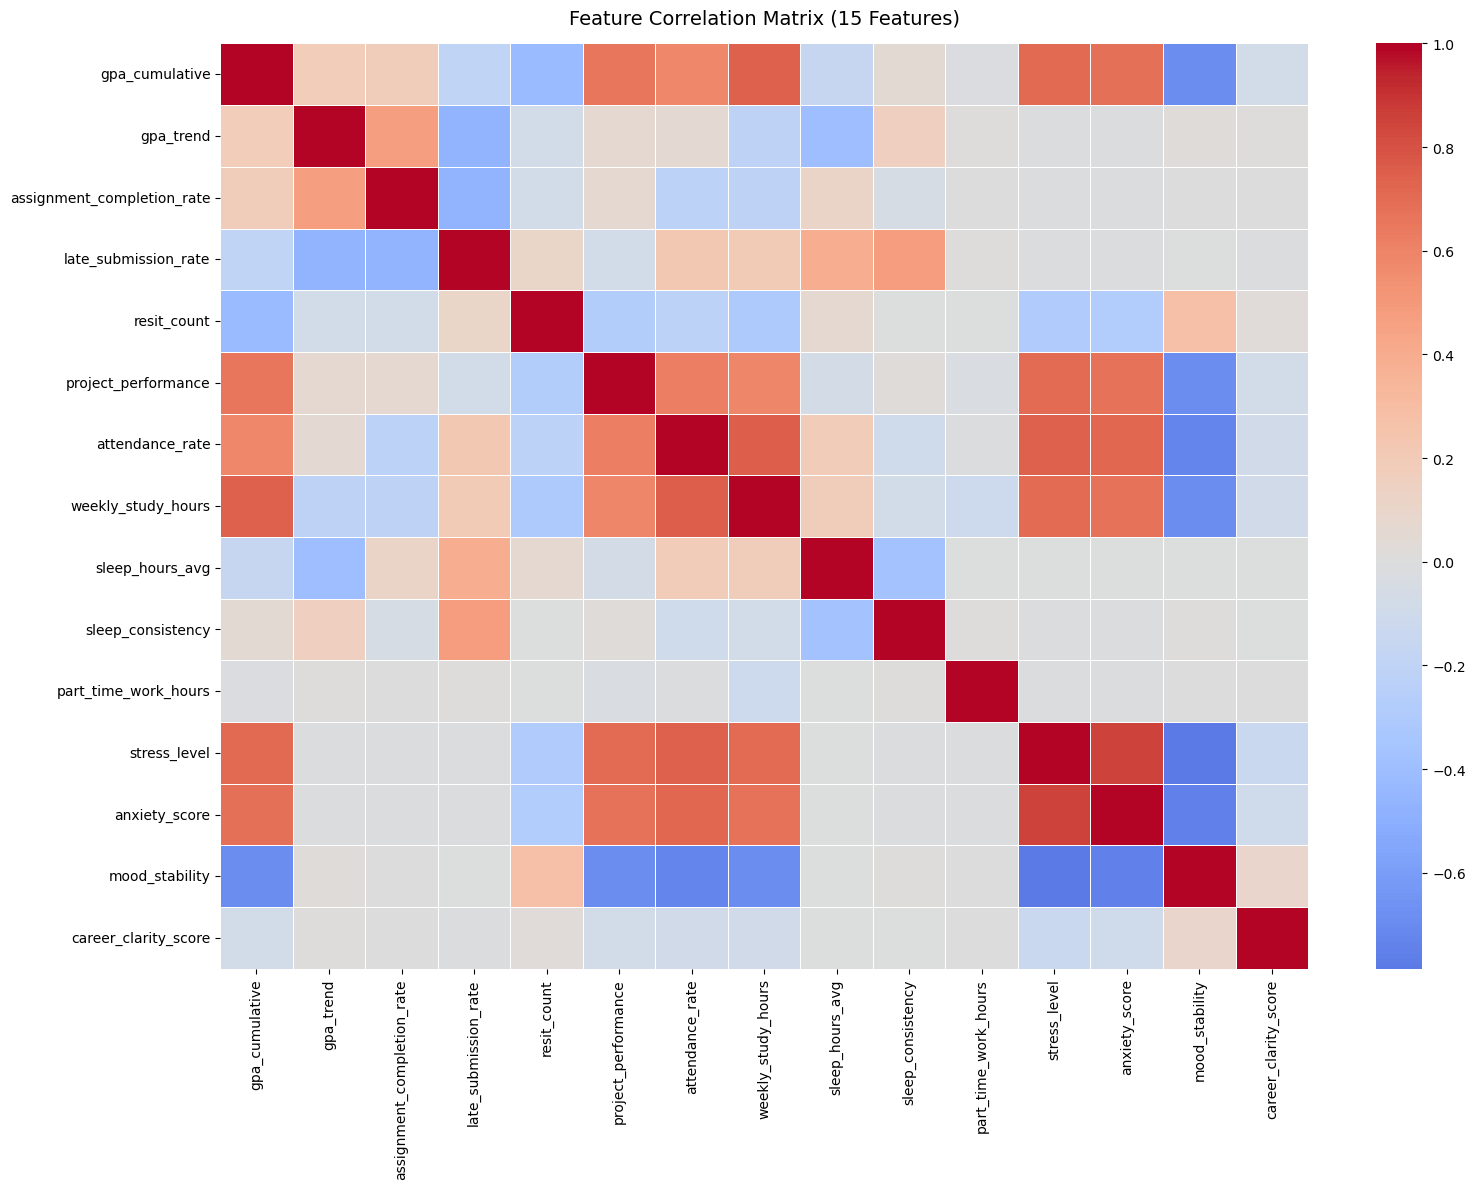


WARNING — 1 pair(s) with |r| > 0.80 (features retained):


,feature_1,feature_2,|r|
0,stress_level,anxiety_score,0.848


In [10]:
corr_matrix = df[FEATURE_COLUMNS].corr()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    corr_matrix, annot=False, cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax
)
ax.set_title('Feature Correlation Matrix (15 Features)', fontsize=14, pad=14)
plt.tight_layout()
corr_path = PLOTS_DIR / 'correlation_matrix.png'
plt.savefig(corr_path, dpi=150)
plt.show()
#print(f'Saved: {corr_path}')

cols      = corr_matrix.columns.tolist()
high_corr = []
for i, col_i in enumerate(cols):
    for col_j in cols[i + 1:]:
        val = abs(corr_matrix.loc[col_i, col_j])
        if val > 0.80:
            high_corr.append({'feature_1': col_i, 'feature_2': col_j, '|r|': round(val, 3)})

if high_corr:
    print(f'\nWARNING — {len(high_corr)} pair(s) with |r| > 0.80 (features retained):')
    display(pd.DataFrame(high_corr))
else:
    print('\nNo highly correlated pairs (all |r| < 0.80).')

### Extract Student Profile Holdout Set (200 Rows)

<!-- **What:** Stratified-sample 200 rows into a separate profile set; remove them from the working dataframe.  
**Why:** These rows serve as ground-truth examples for post-training validation in `model_training.py`. Removing them before any split ensures the trained model never sees them during training or test evaluation. -->

In [14]:
df_profiles, df_main = train_test_split(
    df, train_size=200, random_state=99, stratify=df['academic_risk_encoded']
)
df_profiles = df_profiles.reset_index(drop=True)
df_main     = df_main.reset_index(drop=True)

profile_dist = df_profiles['academic_risk_level'].value_counts()
print(f'Profile holdout  : {len(df_profiles):,} rows  (random_state=99, stratified)')
print(f'Remaining for ML : {len(df_main):,} rows  (expected 9,300)')
print('\nProfile class distribution:')
display(profile_dist.to_frame())

profile_csv_path = PROFILES_DIR / 'student_profiles.csv'
df_profiles.to_csv(profile_csv_path, index=False)
#print(f'\nCSV saved : {profile_csv_path}  {df_profiles.shape}')

profile_pkl_path = SAVED_DIR / 'student_profiles.pkl'
joblib.dump(df_profiles, profile_pkl_path)
loaded_chk = joblib.load(profile_pkl_path)
#print(f'PKL saved : {profile_pkl_path}  verified {loaded_chk.shape}')

Profile holdout  : 200 rows  (random_state=99, stratified)
Remaining for ML : 9,300 rows  (expected 9,300)

Profile class distribution:


,count
academic_risk_level,
Low,145
Medium,43
High,12


### Separate Features and Targets

<!-- **What:** Split `df_main` (9,300 rows) into the 15-column feature matrix `X` and two target vectors.  
**Why:** Keeping X and y as separate objects is required by sklearn's train_test_split and model `.fit()` interfaces. -->

In [15]:
X        = df_main[FEATURE_COLUMNS].copy()
y_risk   = df_main['academic_risk_encoded']
y_career = df_main['career_readiness_score']

print(f'X (features) : {X.shape}')
print(f'y_risk       : {y_risk.shape}  classes {sorted(y_risk.unique())}')
print(f'y_career     : {y_career.shape}  range [{y_career.min():.1f}, {y_career.max():.1f}]')
display(X.describe())

X (features) : (9300, 15)
y_risk       : (9300,)  classes [0, 1, 2]
y_career     : (9300,)  range [46.2, 85.7]


,gpa_cumulative,gpa_trend,assignment_completion_rate,late_submission_rate,resit_count,project_performance,attendance_rate,weekly_study_hours,sleep_hours_avg,sleep_consistency,part_time_work_hours,stress_level,anxiety_score,mood_stability,career_clarity_score
count,9300.000000,9300.000000,9300.000000,9300.000000,9300.000000,9300.000000,9300.000000,9300.000000,9300.000000,9300.000000,9300.000000,9300.000000,9300.000000,9300.00000,9300.000000
mean,3.481633,0.097702,0.796846,0.203094,0.594409,79.425484,0.698215,28.793548,5.478622,1.168891,15.142258,38.269355,9.658925,59.43172,54.383548
std,0.348466,0.276334,0.126951,0.128008,0.806343,8.159775,0.115811,11.928884,0.657883,0.540154,9.733809,20.811885,4.476343,17.40854,16.841361
min,2.040000,-0.940000,0.500000,0.000000,0.000000,50.000000,0.260000,0.000000,3.006590,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,3.240000,-0.080000,0.710000,0.110000,0.000000,74.000000,0.620000,21.000000,5.100000,0.800000,8.000000,24.000000,7.000000,48.00000,43.000000
50%,3.500000,0.100000,0.800000,0.200000,0.000000,80.000000,0.700000,29.000000,5.500000,1.160000,15.000000,38.000000,10.000000,60.00000,54.000000
75%,3.760000,0.280000,0.890000,0.290000,1.000000,85.000000,0.780000,37.000000,5.900000,1.540000,22.000000,52.000000,13.000000,71.00000,66.000000
max,4.000000,1.000000,1.000000,0.500000,5.000000,95.000000,1.000000,68.000000,7.900000,3.150000,40.000000,100.000000,21.000000,100.00000,100.000000


### Train / Test Split

<!-- **What:** 80/20 stratified split for the risk model; 80/20 regular split for the career model.  
**Why:** `stratify=y_risk` ensures Low/Medium/High proportions are preserved in both train and test sets, preventing evaluation bias from a skewed test set. -->

In [16]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_risk, test_size=0.2, random_state=42, stratify=y_risk
)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_career, test_size=0.2, random_state=42
)

print(f'Risk   — Train: {X_train_r.shape}  | Test: {X_test_r.shape}')
print(f'Career — Train: {X_train_c.shape}  | Test: {X_test_c.shape}')
print(f'(expected ~7,440 train / ~1,860 test)')

Risk   — Train: (7440, 15)  | Test: (1860, 15)
Career — Train: (7440, 15)  | Test: (1860, 15)
(expected ~7,440 train / ~1,860 test)


### Scale Features

<!-- **What:** Fit a StandardScaler on the risk training set only, then transform all four splits.  
**Why:** Fitting on training data only prevents test-set statistics from influencing the scaler's mean/std (data leakage). All four splits use the same scaler for consistent feature ranges. -->

In [17]:
scaler = StandardScaler()
X_train_r_scaled = pd.DataFrame(scaler.fit_transform(X_train_r), columns=FEATURE_COLUMNS)
X_test_r_scaled  = pd.DataFrame(scaler.transform(X_test_r),      columns=FEATURE_COLUMNS)
X_train_c_scaled = pd.DataFrame(scaler.transform(X_train_c),     columns=FEATURE_COLUMNS)
X_test_c_scaled  = pd.DataFrame(scaler.transform(X_test_c),      columns=FEATURE_COLUMNS)

print(f'Scaler fitted on X_train_r only ({X_train_r.shape})')
print(f'Risk   scaled — train: {X_train_r_scaled.shape}  | test: {X_test_r_scaled.shape}')
print(f'Career scaled — train: {X_train_c_scaled.shape}  | test: {X_test_c_scaled.shape}')
print('\nScaled training set statistics (should be mean≈0, std≈1):')
display(X_train_r_scaled.describe().round(3))

Scaler fitted on X_train_r only ((7440, 15))
Risk   scaled — train: (7440, 15)  | test: (1860, 15)
Career scaled — train: (7440, 15)  | test: (1860, 15)

Scaled training set statistics (should be mean≈0, std≈1):


,gpa_cumulative,gpa_trend,assignment_completion_rate,late_submission_rate,resit_count,project_performance,attendance_rate,weekly_study_hours,sleep_hours_avg,sleep_consistency,part_time_work_hours,stress_level,anxiety_score,mood_stability,career_clarity_score
count,7440.000,7440.000,7440.000,7440.000,7440.000,7440.000,7440.000,7440.000,7440.000,7440.000,7440.000,7440.000,7440.000,7440.000,7440.000
mean,-0.000,-0.000,-0.000,0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-4.140,-3.769,-2.340,-1.590,-0.738,-3.617,-3.698,-2.422,-3.763,-2.157,-1.552,-1.851,-2.171,-3.409,-3.219
25%,-0.699,-0.648,-0.688,-0.727,-0.738,-0.672,-0.682,-0.660,-0.580,-0.697,-0.729,-0.696,-0.604,-0.647,-0.726
50%,0.046,0.005,0.020,-0.022,-0.738,0.064,0.008,0.011,0.028,-0.013,-0.060,-0.023,0.067,0.044,-0.014
75%,0.792,0.658,0.728,0.684,0.499,0.677,0.697,0.682,0.636,0.689,0.712,0.651,0.739,0.677,0.699
max,1.480,3.271,1.593,2.330,5.447,1.904,2.593,3.284,3.676,3.665,2.563,2.960,2.529,2.346,2.717


### Fix Class Imbalance with SMOTE

<!-- **What:** Apply SMOTE to the risk training set only to balance Low/Medium/High class counts.  
**Why:** If Low-risk students dominate the training set, the classifier learns to predict 'Low' for everything. SMOTE synthesises new minority-class examples via feature-space interpolation without discarding real data. -->

In [18]:
before_counts = pd.Series(y_train_r.values).value_counts().sort_index()
print('Before SMOTE:')
display(before_counts.rename(index=RISK_NAMES).rename('count').to_frame())

smote = SMOTE(random_state=42)
X_train_r_balanced, y_train_r_balanced = smote.fit_resample(X_train_r_scaled, y_train_r)

after_counts = pd.Series(y_train_r_balanced).value_counts().sort_index()
print('After SMOTE:')
display(after_counts.rename(index=RISK_NAMES).rename('count').to_frame())
print('All three classes balanced.')

Before SMOTE:


,count
Low,5402
Medium,1584
High,454


After SMOTE:


,count
academic_risk_encoded,
Low,5402
Medium,5402
High,5402


All three classes balanced.


### Save All Objects

<!-- **What:** Serialise the scaler, feature list, and four data splits to pkl files in `saved_objects/`.  
**Why:** `model_training.py` and `test_inference.py` load these files directly so preprocessing does not need to be re-run every time a model is retrained. -->

In [19]:
# save_targets = {
#     'scaler.pkl'         : scaler,
#     'feature_columns.pkl': FEATURE_COLUMNS,
#     'risk_train.pkl'     : (X_train_r_balanced, y_train_r_balanced),
#     'risk_test.pkl'      : (X_test_r_scaled,    y_test_r),
#     'career_train.pkl'   : (X_train_c_scaled,   y_train_c),
#     'career_test.pkl'    : (X_test_c_scaled,    y_test_c),
# }

# print(f'Saving to: {SAVED_DIR}\n')
# for filename, obj in save_targets.items():
#     path = SAVED_DIR / filename
#     joblib.dump(obj, path)
#     loaded = joblib.load(path)
#     if isinstance(loaded, tuple):
#         parts = ', '.join(
#             str(o.shape) if hasattr(o, 'shape') else f'len={len(o)}'
#             for o in loaded
#         )
#         print(f'  checkmark  {filename:<26} verified  ({parts})')
#     elif isinstance(loaded, list):
#         print(f'  checkmark  {filename:<26} verified  ({len(loaded)} feature names)')
#     else:
#         print(f'  checkmark  {filename:<26} verified  ({type(loaded).__name__})')

### Final Summary

<!-- **What:** Print a structured summary of all preprocessing decisions and outputs.  
**Why:** Provides a single, readable record for the supervisor to verify that every step ran correctly before proceeding to model training. -->

In [22]:
SEP = '=' * 51
after_str = '  |  '.join(f"{RISK_NAMES[k]}={v}" for k, v in after_counts.items())

print(SEP)
print('  PREPROCESSING COMPLETE — SUMMARY')
print(SEP)
print(f'  Original dataset    : 9,500 rows x 27 columns')
print(f'  After dropping cols : {len(df_main) + 200:,} rows x {len(FEATURE_COLUMNS)} features')
print(f'  Missing values fixed: Yes (median imputation)')
print(f'  Targets created     : career_readiness_score (regression)')
print(f'                        academic_risk_level (classification)')
print(f'  Profile holdout     : 200 rows (saved separately)')
print(f'  Training rows       : {len(X_train_r_balanced):,}')
print(f'  Test rows           : {len(X_test_r_scaled):,}')
print(f'  Features            : {len(FEATURE_COLUMNS)}')
for domain, fcols in FEATURE_DOMAINS.items():
    print(f'    {domain.capitalize():10s} ({len(fcols)}): {", ".join(fcols)}')
print(f'  Class balance :')
print(f'    {after_str}')
# print(f'  Saved objects       : {SAVED_DIR}')
# print(f'  Profile CSV         : {profile_csv_path}')
# print(f'  Correlation plot    : {corr_path}')
print(SEP)
print('  Ready for model_training.py')
print(SEP)

  PREPROCESSING COMPLETE — SUMMARY
  Original dataset    : 9,500 rows x 27 columns
  After dropping cols : 9,500 rows x 15 features
  Missing values fixed: Yes (median imputation)
  Targets created     : career_readiness_score (regression)
                        academic_risk_level (classification)
  Profile holdout     : 200 rows (saved separately)
  Training rows       : 16,206
  Test rows           : 1,860
  Features            : 15
    Academic   (6): gpa_cumulative, gpa_trend, assignment_completion_rate, late_submission_rate, resit_count, project_performance
    Behavioral (5): attendance_rate, weekly_study_hours, sleep_hours_avg, sleep_consistency, part_time_work_hours
    Emotional  (3): stress_level, anxiety_score, mood_stability
    Career     (1): career_clarity_score
  Class balance :
    Low=5402  |  Medium=5402  |  High=5402
  Ready for model_training.py
